## 주가 데이터 분석

- `yfinance` 라이브러리를 사용하여 주가 데이터를 수집합니다. (2020-01-01 ~ 현재)
- 날짜 인덱스와 결측 개념을 확인합니다.
- 일간 수익률과 누적 수익률을 계산합니다.
- 장기 투자 성과를 선 그래프로 시각화합니다.

### 필요한 모듈 임포트

In [3]:
# Colab에서 필요한 라이브러리 설치 여부를 확인합니다.
# [참고] 코드 실행 결과 콘솔에 아무것도 출력되지 않으면 현재 Colab에는
# 'yfinance'를 포함하는 라이브러리가 설치되지 않았다는 것을 의미합니다.
!pip list | grep yfinance

yfinance                              0.2.66


In [5]:
# 필요한 라이브러리를 설치합니다.
# !pip install yfinance

In [6]:
# 필요한 모듈을 임포트합니다.
import numpy as np
import pandas as pd
import yfinance as yf

### 주가 데이터 수집

In [7]:
# 티커를 설정합니다.
ticker = '005930.KS'

In [8]:
# 주가 데이터 수집 시작일자를 설정합니다.
# [참고] 단순 수익률을 계산할 때 첫 번째 행은 결측이 되므로 시작일자를
# 데이터 수집 기간의 시작일보다 하루 앞당긴 날자로 지정합니다.
start_date = '2019-12-31'

In [9]:
# 주가 데이터 수집 종료일자를 설정합니다.
# [참고] 주가 수집 함수가 마지막 일자를 포함하지 않습니다.
# 아래 코드를 실행하면 시스템 날짜를 end_date에 할당합니다.
end_date = pd.Timestamp.today().strftime(format='%Y-%m-%d')
end_date

'2026-07-25'

In [10]:
# 주가 데이터를 수집하고 데이터프레임을 생성합니다.
# [참고] end 매개변수에 지정한 날짜를 포함하지 않습니다.
# auto_adjust 매개변수를 생략하면 배당과 액면분할 반영하여 OLHC를 조정합니다.
df = yf.download(tickers=ticker, start=start_date, end=end_date)

/tmp/ipykernel_2125/1309862101.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


### 데이터프레임 구조 확인

In [14]:
# df의 처음 5행을 확인합니다.
# [참고] n 매개변수에 출력할 행 개수를 정수로 설정합니다.(기본값: 5)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2020-01-02,47372.855469,48059.418591,47201.214688,47630.316640,12993228
2020-01-03,47630.300781,48574.324761,47115.378611,48059.402590,15422255
2020-01-06,47630.300781,47716.121143,46857.917525,47115.378611,10278951
2020-01-07,47887.773438,48402.695733,47716.132672,47801.953055,10009778
2020-01-08,48745.972656,49260.894903,47973.589287,48231.050410,23501171


In [15]:
# df의 열이름을 확인합니다.
# [참고] 열이름이 멀티 인덱스로 생성되었습니다.
# 열이름 네임은 ['Price', 'Ticker']로 설정되었습니다.
df.columns

MultiIndex([( 'Close', '005930.KS'),
            (  'High', '005930.KS'),
            (   'Low', '005930.KS'),
            (  'Open', '005930.KS'),
            ('Volume', '005930.KS')],
           names=['Price', 'Ticker'])

In [16]:
df.columns.get_level_values(level=0)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [17]:
# df의 열이름에서 첫 번째 레벨만 남깁니다.
# [참고] df.columns.droplevel(level=1)은 두 번째 레벨을 삭제합니다.
df.columns = df.columns.get_level_values(level=0)

In [18]:
# df의 열이름을 확인합니다.
# [참고] df의 열이름 네임이 'Price'로 남아 있습니다.
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [19]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,47372.855469,48059.418591,47201.214688,47630.316640,12993228
2020-01-03,47630.300781,48574.324761,47115.378611,48059.402590,15422255
2020-01-06,47630.300781,47716.121143,46857.917525,47115.378611,10278951
2020-01-07,47887.773438,48402.695733,47716.132672,47801.953055,10009778
2020-01-08,48745.972656,49260.894903,47973.589287,48231.050410,23501171


In [20]:
df.columns.name

'Price'

In [21]:
# df의 열이름 네임을 삭제합니다.
# [참고] df.columns.name에 None을 할당하면 열이름 네임을 초기화합니다.
df.columns.name = None

In [22]:
# df의 처음 5행을 확인합니다.
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,47372.855469,48059.418591,47201.214688,47630.316640,12993228
2020-01-03,47630.300781,48574.324761,47115.378611,48059.402590,15422255
2020-01-06,47630.300781,47716.121143,46857.917525,47115.378611,10278951
2020-01-07,47887.773438,48402.695733,47716.132672,47801.953055,10009778
2020-01-08,48745.972656,49260.894903,47973.589287,48231.050410,23501171


In [23]:
# 주가 데이터를 수집하고 데이터프레임을 생성합니다.
# [참고] auto_adjust 매개변수에 False를 지정하면 OHLC를 유지하고 수정 종가를 추가합니다.(기본값: True)
# progress 매개변수에 False를 지정하면 다운로드 진행 막대를 출력하지 않습니다.(기본값: True)
# multi_level_index 매개변수에 False를 지정하면 단일 레벨 열이름을 반환합니다.(기본값: True)
df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False,
    multi_level_index=False,
)

### 데이터프레임 전처리

In [24]:
# df의 처음 5행을 확인합니다.
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,47372.855469,55200.0,56000.0,55000.0,55500.0,12993228
2020-01-03,47630.300781,55500.0,56600.0,54900.0,56000.0,15422255
2020-01-06,47630.300781,55500.0,55600.0,54600.0,54900.0,10278951
2020-01-07,47887.773438,55800.0,56400.0,55600.0,55700.0,10009778
2020-01-08,48745.972656,56800.0,57400.0,55900.0,56200.0,23501171


In [31]:
# [참고] 데이터프레임에서 하나의 행 또는 하나의 열을 선택하면 시리즈로 반환합니다.
df.loc[:, 'Close':'Volume']

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,55200.0,56000.0,55000.0,55500.0,12993228
2020-01-03,55500.0,56600.0,54900.0,56000.0,15422255
2020-01-06,55500.0,55600.0,54600.0,54900.0,10278951
2020-01-07,55800.0,56400.0,55600.0,55700.0,10009778
2020-01-08,56800.0,57400.0,55900.0,56200.0,23501171
...,...,...,...,...,...
2026-07-20,244000.0,257500.0,240000.0,241000.0,26804038
2026-07-21,259000.0,263500.0,243000.0,247000.0,20386896
2026-07-22,260500.0,276000.0,260000.0,276000.0,22292003


In [32]:
# df의 열 순서를 변경하기 위해 열이름 리스트를 생성합니다.
# [참고] 이번 실습에서 수정 종가를 사용하지 않을 예정이므로 제외합니다.
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

In [33]:
# df의 열 순서를 변경하고 df에 재할당합니다.
df = df.loc[:, cols]

In [34]:
# df의 처음 5행을 확인합니다.
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171


### 날짜 인덱스 전처리

In [35]:
# df의 정보를 확인합니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1607 entries, 2020-01-02 to 2026-07-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1607 non-null   float64
 1   High    1607 non-null   float64
 2   Low     1607 non-null   float64
 3   Close   1607 non-null   float64
 4   Volume  1607 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.3 KB


In [36]:
# df의 인덱스를 확인합니다.
# [참고] df의 인덱스는 DatetimeIndex입니다.
df.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-07-10', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-20', '2026-07-21', '2026-07-22',
               '2026-07-23', '2026-07-24'],
              dtype='datetime64[ns]', name='Date', length=1607, freq=None)

In [37]:
# df의 인덱스를 초기화하고 기존 인덱스를 첫 번째 열로 삽입한 결과를 df에 재할당합니다.
df = df.reset_index()

In [38]:
# df의 처음 5행을 확인합니다.
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
1,2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2,2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
3,2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
4,2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171


In [39]:
# df의 열별 자료형을 확인합니다.
df.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


In [40]:
# df에서 Date를 문자열로 변환합니다.
df['Date'] = df['Date'].astype(dtype=str)

In [41]:
# df의 열별 자료형을 확인합니다.
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


In [42]:
# df의 행 순서를 무작위로 섞은 결과를 df에 재할당합니다.
df = df.sample(frac=1, random_state=1, ignore_index=True)

In [43]:
# df의 처음 5행을 확인합니다.
df.head()

,Date,Open,High,Low,Close,Volume
0,2024-12-18,54100.0,55400.0,54000.0,54900.0,13698937
1,2023-07-21,70400.0,70400.0,69400.0,70300.0,16528926
2,2022-02-21,74300.0,74300.0,74300.0,74300.0,0
3,2021-12-30,78900.0,79500.0,78100.0,78300.0,14236700
4,2022-09-06,57200.0,57600.0,56900.0,57100.0,7503086


In [44]:
# df에서 Date를 날짜시간형으로 변환합니다.
df['Date'] = pd.to_datetime(arg=df['Date'])

In [45]:
# df의 열별 자료형을 확인합니다.
df.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


In [46]:
# df에서 Date를 인덱스로 설정하고 df에 재할당합니다.
df = df.set_index(keys='Date')

In [47]:
# df의 처음 5행을 확인합니다.
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-12-18,54100.0,55400.0,54000.0,54900.0,13698937
2023-07-21,70400.0,70400.0,69400.0,70300.0,16528926
2022-02-21,74300.0,74300.0,74300.0,74300.0,0
2021-12-30,78900.0,79500.0,78100.0,78300.0,14236700
2022-09-06,57200.0,57600.0,56900.0,57100.0,7503086


In [48]:
# df를 인덱스 기준으로 오름차순 정렬하고 df에 재할당합니다.
df = df.sort_index()

In [49]:
# df의 처음 5행을 확인합니다.
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171


### [참고] 누락된 인덱스 추가 및 결측값 처리

- 주식 데이터는 거래일에만 값이 존재합니다.
- 따라서 누락된 인덱스는 주말 또는 공휴일입니다.
- 만약 누락된 인덱스를 추가하면 해당일은 결측값(`np.nan`)으로 채워집니다.
- 연속적인 시계열 데이터는 누락된 인덱스를 추가하고 선형 보간법 등을 사용하여 결측을 채웁니다.

In [50]:
# df의 인덱스를 일(day) 단위로 재생성하고 처음 5행만 선택하여 df_na에 할당합니다.
df_na = df.asfreq(freq='D').head()

In [51]:
# df_na를 확인합니다.
df_na

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228.0
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255.0
2020-01-04,NaN,NaN,NaN,NaN,NaN
2020-01-05,NaN,NaN,NaN,NaN,NaN
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951.0


In [52]:
# df_na에서 종가에 있는 결측값을 직전 값으로 채운 결과를 확인합니다.
df_na['Close'].ffill()

,Close
Date,
2020-01-02,55200.0
2020-01-03,55500.0
2020-01-04,55500.0
2020-01-05,55500.0
2020-01-06,55500.0


In [53]:
# df_na에서 종가에 있는 결측값을 선형 보간법으로 채운 결과를 확인합니다.
# [주의] 주식 데이터의 결측값을 선형 보간법으로 함부로 채우면 안 됩니다.
df_na['Close'].interpolate(method='linear')

,Close
Date,
2020-01-02,55200.0
2020-01-03,55500.0
2020-01-04,55500.0
2020-01-05,55500.0
2020-01-06,55500.0


In [54]:
df_na['Open'].interpolate(method='linear')

,Open
Date,
2020-01-02,55500.000000
2020-01-03,56000.000000
2020-01-04,55633.333333
2020-01-05,55266.666667
2020-01-06,54900.000000


### [참고] 전역 변수 목록 확인 및 변수 삭제

In [55]:
# 전역 변수 목록을 확인합니다.
%whos

Variable     Type         Data/Info
-----------------------------------
cols         list         n=5
df           DataFrame                    Open     <...>\n[1607 rows x 5 columns]
df_na        DataFrame                   Open     H<...>00.0  55500.0  10278951.0
end_date     str          2026-07-25
np           module       <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd           module       <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
start_date   str          2019-12-31
ticker       str          005930.KS
yf           module       <module 'yfinance' from '<...>es/yfinance/__init__.py'>


In [56]:
# 전역 변수 목록에서 데이터프레임만 확인합니다.
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
df         DataFrame                    Open     <...>\n[1607 rows x 5 columns]
df_na      DataFrame                   Open     H<...>00.0  55500.0  10278951.0


In [57]:
# df_na를 전역 변수 목록에서 삭제합니다.
del df_na

In [58]:
# 전역 변수 목록에서 데이터프레임만 확인합니다.
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
df         DataFrame                    Open     <...>\n[1607 rows x 5 columns]


### 날짜 인덱스 필터링

In [59]:
# df에서 2020년도 데이터만 선택합니다.(인덱싱)
# [참고] df에는 'yyyy' 형태의 행이름은 없지만, df의 인덱스가 날짜 인덱스이므로
# 네자리 정수를 지정하여 원하는 연도를 인덱싱할 수 있습니다.
df.loc['2020']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171
...,...,...,...,...,...
2020-12-23,72400.0,74000.0,72300.0,73900.0,19411326
2020-12-24,74100.0,78800.0,74000.0,77800.0,32502870
2020-12-28,79000.0,80100.0,78200.0,78700.0,40085044


In [60]:
# df에서 2020년 1월 데이터만 선택합니다.(인덱싱)
# [참고] 'yyyy-mm' 형태의 지정하여 특정 연도와 월까지 함께 지정할 수 있습니다.
# [주의] 인덱스의 부분 문자열에 대해 팬시 인덱싱과 슬라이싱을 지원하지 않습니다.
df.loc['2020-01']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171
2020-01-09,58400.0,58600.0,57400.0,58600.0,24102579
2020-01-10,58800.0,59700.0,58300.0,59500.0,16000170
2020-01-13,59600.0,60000.0,59100.0,60000.0,11359139
2020-01-14,60400.0,61000.0,59900.0,60000.0,16906295


In [61]:
# df에서 2020년 1월 2일과 3일 데이터만 선택합니다.(팬시 인덱싱)
df.loc[['2020-01-02', '2020-01-03']]

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255


In [62]:
# df에서 2020년 1월 1~7일 데이터만 선택합니다.(슬라이싱)
df.loc['2020-01-01':'2020-01-07']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778


### 날짜 인덱스의 속성 활용

In [63]:
# df에서 매년 1월 데이터만 선택합니다.(불리언 인덱싱)
df.loc[df.index.month == 1]

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171
...,...,...,...,...,...
2026-01-26,154900.0,156400.0,151500.0,152100.0,20561689
2026-01-27,150500.0,159500.0,149200.0,159500.0,29423670
2026-01-28,162600.0,163300.0,160200.0,162400.0,29456431


In [64]:
# df에서 매년 12월 31일 데이터만 선택합니다.
df.loc[(df.index.month == 12) & (df.index.day == 31)]

,Open,High,Low,Close,Volume
Date,,,,,


In [65]:
# df의 인덱스에서 정수 요일을 생성합니다.
# [참고] 정수 0은 Monday, 정수 6은 Sunday입니다.
df.index.dayofweek

Index([3, 4, 0, 1, 2, 3, 4, 0, 1, 2,
       ...
       4, 0, 1, 2, 3, 0, 1, 2, 3, 4],
      dtype='int32', name='Date', length=1607)

In [66]:
# df에서 매주 월요일 데이터만 선택합니다.
df.loc[df.index.dayofweek == 0]

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951
2020-01-13,59600.0,60000.0,59100.0,60000.0,11359139
2020-01-20,62000.0,62800.0,61700.0,62400.0,12528855
2020-02-03,55500.0,57400.0,55200.0,57200.0,23995260
2020-02-10,59200.0,59800.0,59100.0,59700.0,13107121
...,...,...,...,...,...
2026-06-22,343000.0,363000.0,342000.0,353500.0,24330451
2026-06-29,331000.0,335500.0,316000.0,323000.0,35436521
2026-07-06,320000.0,325000.0,303000.0,318000.0,23872879


In [67]:
# df의 인덱스에서 영문 요일 문자열을 생성합니다.
# [참고] date_format 매개변수에 지정한 날짜 포맷에 맞는 문자열을 반환합니다.
df.index.strftime(date_format='%A')

Index(['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
       'Friday', 'Monday', 'Tuesday', 'Wednesday',
       ...
       'Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
      dtype='object', name='Date', length=1607)

In [68]:
# df의 인덱스에서 영문 요일 문자열을 생성합니다.
# [참고] locale 매개변수에 'ko_KR'을 지정하면 요일을 한글 문자열로 반환합니다.
# [주의] Colab 환경에서는 한국 로케일을 바로 사용할 수 없습니다.
df.index.day_name()

Index(['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
       'Friday', 'Monday', 'Tuesday', 'Wednesday',
       ...
       'Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
      dtype='object', name='Date', length=1607)

In [69]:
# 한글 요일 문자열을 매핑할 딕셔너리를 생성합니다.
weekday_kor = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

In [70]:
# df의 인덱스에서 정수 요일을 추출하고, 한글 요일명으로 매핑합니다.
df.index.dayofweek.map(mapper=weekday_kor)

Index(['목', '금', '월', '화', '수', '목', '금', '월', '화', '수',
       ...
       '금', '월', '화', '수', '목', '월', '화', '수', '목', '금'],
      dtype='object', name='Date', length=1607)

### [참고] 집계 함수 활용법

In [71]:
# df에서 매년 첫 번째 거래일 데이터만 선택합니다.
# [참고] first 메서드는 그룹 집계 함수이므로, 그룹 키를 새로운 인덱스로 설정합니다.
df.groupby(by=df.index.year).first()

,Open,High,Low,Close,Volume
Date,,,,,
2020,55500.0,56000.0,55000.0,55200.0,12993228
2021,81000.0,84400.0,80200.0,83000.0,38655276
2022,78800.0,79200.0,78300.0,78700.0,12427416
2023,55500.0,56100.0,55200.0,55500.0,10031448
2024,78200.0,79800.0,78200.0,79600.0,17142847
2025,52700.0,53600.0,52300.0,53400.0,16630538
2026,120200.0,128500.0,120200.0,128500.0,30463279


In [72]:
# df에서 매년 마지막 거래일 데이터만 선택합니다.
df.groupby(by=df.index.year).last()

,Open,High,Low,Close,Volume
Date,,,,,
2020,77400.0,81300.0,77300.0,81000.0,29417421
2021,78900.0,79500.0,78100.0,78300.0,14236700
2022,56000.0,56200.0,55300.0,55300.0,11295935
2023,77700.0,78500.0,77500.0,78500.0,17797536
2024,53300.0,54000.0,53100.0,53200.0,12624702
2025,119100.0,121200.0,118700.0,119900.0,19746349
2026,266000.0,266500.0,247000.0,249500.0,26175580


In [73]:
# df에서 매년 첫 번째 거래일 데이터만 선택합니다.
# [참고] nth 메서드는 n번째 행을 선택하는 함수이므로, 원본 인덱스를 유지합니다.
df.groupby(by=df.index.year).nth(n=0)

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228
2021-01-04,81000.0,84400.0,80200.0,83000.0,38655276
2022-01-04,78800.0,79200.0,78300.0,78700.0,12427416
2023-01-02,55500.0,56100.0,55200.0,55500.0,10031448
2024-01-02,78200.0,79800.0,78200.0,79600.0,17142847
2025-01-02,52700.0,53600.0,52300.0,53400.0,16630538
2026-01-02,120200.0,128500.0,120200.0,128500.0,30463279


In [74]:
# df에서 매년 마지막 거래일 데이터만 선택합니다.
df.groupby(by=df.index.year).nth(n=-1)

,Open,High,Low,Close,Volume
Date,,,,,
2020-12-30,77400.0,81300.0,77300.0,81000.0,29417421
2021-12-30,78900.0,79500.0,78100.0,78300.0,14236700
2022-12-29,56000.0,56200.0,55300.0,55300.0,11295935
2023-12-28,77700.0,78500.0,77500.0,78500.0,17797536
2024-12-30,53300.0,54000.0,53100.0,53200.0,12624702
2025-12-30,119100.0,121200.0,118700.0,119900.0,19746349
2026-07-24,266000.0,266500.0,247000.0,249500.0,26175580


### 수익률 계산

- 이번 예제에서 다루는 수익률은 투자 수익률이 아니고 가격 변화율(시장 수익률)입니다.
- 투자 수익률은 체결(진입/청산) 가격을 기준으로 계산해야 합니다.

In [79]:
# 단순 수익률을 계산하고 df에 추가합니다.
# [참고] pct_change 메서드는 직전 값 대비 현재 값의 변화율을 반환합니다.
# 따라서 실제 투자 수익률과는 다릅니다.
df['Daily_Return'] = df['Close'].pct_change()

In [80]:
# 로그 수익률을 계산하고 df에 추가합니다.
# [참고] 로그 수익률은 시계열 분석 및 통계 모델링에 더 적합합니다.
# shift 메서드는 periods 매개변수에 지정한 정수만큼 위(음수), 아래(양수)로 이동시킵니다.
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(periods=1))

In [81]:
# df에서 열별 결측값 개수를 확인합니다.
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Daily_Return,1
Log_Return,1


In [82]:
# df에서 결측값을 0으로 대체하고 df에 재할당합니다.
# [참고] dropna 메서드의 axis 매개변수에 0을 지정하면 결측을 포함하는 행,
# 1을 지정하면 결측을 포함하는 열을 삭제합니다.(기본값: 0)
df = df.fillna(value=0)

In [83]:
# 누적 수익률을 계산하고 df에 추가합니다.
# [참고] 단순 수익률에 1을 더하여 원금을 1로 설정합니다.
# Cum_Return은 매 시점의 종가가 초기 대비 몇 배가 되었는지를 의미합니다.
df['Cum_Return'] = (df['Daily_Return'] + 1).cumprod()

In [84]:
# df의 처음 10행을 확인합니다.
df.head(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return
Date,,,,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228,0.000000,0.000000,1.000000
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255,0.005435,0.005420,1.005435
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951,0.000000,0.000000,1.005435
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778,0.005405,0.005391,1.010870
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171,0.017921,0.017762,1.028986
2020-01-09,58400.0,58600.0,57400.0,58600.0,24102579,0.031690,0.031198,1.061594
2020-01-10,58800.0,59700.0,58300.0,59500.0,16000170,0.015358,0.015242,1.077899
2020-01-13,59600.0,60000.0,59100.0,60000.0,11359139,0.008403,0.008368,1.086957
2020-01-14,60400.0,61000.0,59900.0,60000.0,16906295,0.000000,0.000000,1.086957


In [85]:
# df의 마지막 10행을 확인합니다.
df.tail(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return
Date,,,,,,,,
2026-07-10,291000.0,298000.0,282000.0,285000.0,20088811,0.025180,0.024868,5.163043
2026-07-13,285000.0,292500.0,253000.0,254500.0,31882652,-0.107018,-0.113188,4.610507
2026-07-14,255000.0,270000.0,247000.0,263000.0,40086496,0.033399,0.032853,4.764493
2026-07-15,283500.0,284500.0,273000.0,279500.0,24873414,0.062738,0.060848,5.063406
2026-07-16,264500.0,265500.0,252500.0,255000.0,27001478,-0.087657,-0.091739,4.619565
2026-07-20,241000.0,257500.0,240000.0,244000.0,26804038,-0.043137,-0.044095,4.420290
2026-07-21,247000.0,263500.0,243000.0,259000.0,20386896,0.061475,0.059660,4.692029
2026-07-22,276000.0,276000.0,260000.0,260500.0,22292003,0.005792,0.005775,4.719203
2026-07-23,269000.0,273000.0,263000.0,270000.0,16011816,0.036468,0.035819,4.891304


In [86]:
# 로그 누적 수익률을 계산하고 일반 수익률로 변환합니다.
# [참고] 단순 수익률을 누적하려면 곱셈이 필요하지만, 로그 수익률은 합산합니다.
# 로그 누적 수익률을 지수 변환하면 단순 누적 수익률과 동일한 값이 됩니다.
np.exp(df['Log_Return'].cumsum())

,Log_Return
Date,
2020-01-02,1.000000
2020-01-03,1.005435
2020-01-06,1.005435
2020-01-07,1.010870
2020-01-08,1.028986
...,...
2026-07-20,4.420290
2026-07-21,4.692029
2026-07-22,4.719203


In [87]:
# 누적 수익률의 백분율을 계산하고 df에 추가합니다.
# [참고] Cum_Return에서 1을 차감하고 100을 곱하여 순수 수익률을 확인합니다.
# 누적 수익률은 1을 기준으로 배수 형태로 계산하지만, 실제로 해석할 때에는
# 원금을 제외한 수익 부분이 중요하므로 누적 수익률에서 1을 차감합니다.
df['Cum_Return_Pct'] = (df['Cum_Return'] - 1) * 100

In [88]:
# df의 마지막 10행을 확인합니다.
df.tail(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return,Cum_Return_Pct
Date,,,,,,,,,
2026-07-10,291000.0,298000.0,282000.0,285000.0,20088811,0.025180,0.024868,5.163043,416.304348
2026-07-13,285000.0,292500.0,253000.0,254500.0,31882652,-0.107018,-0.113188,4.610507,361.050725
2026-07-14,255000.0,270000.0,247000.0,263000.0,40086496,0.033399,0.032853,4.764493,376.449275
2026-07-15,283500.0,284500.0,273000.0,279500.0,24873414,0.062738,0.060848,5.063406,406.340580
2026-07-16,264500.0,265500.0,252500.0,255000.0,27001478,-0.087657,-0.091739,4.619565,361.956522
2026-07-20,241000.0,257500.0,240000.0,244000.0,26804038,-0.043137,-0.044095,4.420290,342.028986
2026-07-21,247000.0,263500.0,243000.0,259000.0,20386896,0.061475,0.059660,4.692029,369.202899
2026-07-22,276000.0,276000.0,260000.0,260500.0,22292003,0.005792,0.005775,4.719203,371.920290
2026-07-23,269000.0,273000.0,263000.0,270000.0,16011816,0.036468,0.035819,4.891304,389.130435


In [89]:
# 시작 종가와 마지막 종가를 각각 생성합니다.
base_close, last_close = df['Close'].iloc[[0, -1]]

In [90]:
# 전체 기간 누적 수익률을 확인합니다.
(last_close / base_close - 1) * 100

351.9927536231884

### 변동성 계산

In [91]:
# 단순 수익률의 평균을 확인합니다.
df['Daily_Return'].mean()

np.float64(0.0011956062573486184)

In [92]:
# 단순 수익률의 표준편차를 확인합니다.
df['Daily_Return'].std()

0.022701878486868554

In [96]:
# 단순 수익률의 20일 이동 표준편차를 계산하고 df에 추가합니다.
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()

In [97]:
# df의 마지막 10행을 확인합니다.
df.tail(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return,Cum_Return_Pct,Volatility_20
Date,,,,,,,,,,
2026-07-10,291000.0,298000.0,282000.0,285000.0,20088811,0.025180,0.024868,5.163043,416.304348,0.059442
2026-07-13,285000.0,292500.0,253000.0,254500.0,31882652,-0.107018,-0.113188,4.610507,361.050725,0.062431
2026-07-14,255000.0,270000.0,247000.0,263000.0,40086496,0.033399,0.032853,4.764493,376.449275,0.062919
2026-07-15,283500.0,284500.0,273000.0,279500.0,24873414,0.062738,0.060848,5.063406,406.340580,0.064927
2026-07-16,264500.0,265500.0,252500.0,255000.0,27001478,-0.087657,-0.091739,4.619565,361.956522,0.065869
2026-07-20,241000.0,257500.0,240000.0,244000.0,26804038,-0.043137,-0.044095,4.420290,342.028986,0.066144
2026-07-21,247000.0,263500.0,243000.0,259000.0,20386896,0.061475,0.059660,4.692029,369.202899,0.068348
2026-07-22,276000.0,276000.0,260000.0,260500.0,22292003,0.005792,0.005775,4.719203,371.920290,0.063335
2026-07-23,269000.0,273000.0,263000.0,270000.0,16011816,0.036468,0.035819,4.891304,389.130435,0.059311


### 이동 평균 계산

In [98]:
# 종가의 20일 이동 평균을 계산하고 df에 추가합니다.
df['Moving_Avg_20'] = df['Close'].rolling(window=20).mean()

In [99]:
# 종가의 60일 이동 평균을 계산하고 df에 추가합니다.
df['Moving_Avg_60'] = df['Close'].rolling(window=60).mean()

In [100]:
# df의 처음 10행을 확인합니다.
df.head(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return,Cum_Return_Pct,Volatility_20,Moving_Avg_20,Moving_Avg_60
Date,,,,,,,,,,,,
2020-01-02,55500.0,56000.0,55000.0,55200.0,12993228,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN
2020-01-03,56000.0,56600.0,54900.0,55500.0,15422255,0.005435,0.005420,1.005435,0.543478,NaN,NaN,NaN
2020-01-06,54900.0,55600.0,54600.0,55500.0,10278951,0.000000,0.000000,1.005435,0.543478,NaN,NaN,NaN
2020-01-07,55700.0,56400.0,55600.0,55800.0,10009778,0.005405,0.005391,1.010870,1.086957,NaN,NaN,NaN
2020-01-08,56200.0,57400.0,55900.0,56800.0,23501171,0.017921,0.017762,1.028986,2.898551,NaN,NaN,NaN
2020-01-09,58400.0,58600.0,57400.0,58600.0,24102579,0.031690,0.031198,1.061594,6.159420,NaN,NaN,NaN
2020-01-10,58800.0,59700.0,58300.0,59500.0,16000170,0.015358,0.015242,1.077899,7.789855,NaN,NaN,NaN
2020-01-13,59600.0,60000.0,59100.0,60000.0,11359139,0.008403,0.008368,1.086957,8.695652,NaN,NaN,NaN
2020-01-14,60400.0,61000.0,59900.0,60000.0,16906295,0.000000,0.000000,1.086957,8.695652,NaN,NaN,NaN


In [101]:
# df의 마지막 10행을 확인합니다.
df.tail(n=10)

,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Cum_Return,Cum_Return_Pct,Volatility_20,Moving_Avg_20,Moving_Avg_60
Date,,,,,,,,,,,,
2026-07-10,291000.0,298000.0,282000.0,285000.0,20088811,0.025180,0.024868,5.163043,416.304348,0.059442,323325.0,288958.333333
2026-07-13,285000.0,292500.0,253000.0,254500.0,31882652,-0.107018,-0.113188,4.610507,361.050725,0.062431,319200.0,289758.333333
2026-07-14,255000.0,270000.0,247000.0,263000.0,40086496,0.033399,0.032853,4.764493,376.449275,0.062919,315200.0,290625.000000
2026-07-15,283500.0,284500.0,273000.0,279500.0,24873414,0.062738,0.060848,5.063406,406.340580,0.064927,311850.0,291658.333333
2026-07-16,264500.0,265500.0,252500.0,255000.0,27001478,-0.087657,-0.091739,4.619565,361.956522,0.065869,306475.0,292308.333333
2026-07-20,241000.0,257500.0,240000.0,244000.0,26804038,-0.043137,-0.044095,4.420290,342.028986,0.066144,300975.0,292800.000000
2026-07-21,247000.0,263500.0,243000.0,259000.0,20386896,0.061475,0.059660,4.692029,369.202899,0.068348,296250.0,293466.666667
2026-07-22,276000.0,276000.0,260000.0,260500.0,22292003,0.005792,0.005775,4.719203,371.920290,0.063335,293775.0,294183.333333
2026-07-23,269000.0,273000.0,263000.0,270000.0,16011816,0.036468,0.035819,4.891304,389.130435,0.059311,290250.0,294941.666667


### Colab에서 한글 폰트 설치

In [102]:
# 현재 Colab에 설치된 폰트 목록을 확인합니다.
!fc-list

/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf: Liberation Sans Narrow:style=Italic
/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf: Liberation Sans:style=Regular
/usr/share/fonts/truetype/liberation/LiberationMono-BoldItalic.ttf: Liberation Mono:style=Bold Italic
/usr/share/fonts/truetype/liberation/LiberationSerif-Italic.ttf: Liberation Serif:style=Italic
/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf: Liberation Mono:style=Bold
/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf: Liberation Sans Narrow:style=Regular
/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf: Liberation Serif:style=Bold
/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf: Liberation Mono:style=Regular
/usr/share/fonts/truetype/liberation/LiberationSans-Italic.ttf: Liberation Sans:style=Italic
/usr/share/fonts/truetype/liberation/LiberationSerif-BoldItalic.ttf: Liberation Serif:style=Bold Italic
/usr/share/fonts/truet

In [103]:
# 불필요한 경로를 제거하고 전체 폰트 이름만 출력합니다.
!fc-list : family

Liberation Sans Narrow
Liberation Mono
Liberation Serif
Humor Sans
Liberation Sans


In [104]:
# Colab에서 사용할 나눔 폰트를 설치합니다.
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (27.2 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [105]:
# 불필요한 경로를 제거하고 한글 폰트 이름만 중복 없이 오름차순 정렬하여 출력합니다.
!fc-list :lang=ko family | sort | uniq

NanumBarunGothic,나눔바른고딕
NanumGothic,나눔고딕
NanumGothicCoding,나눔고딕코딩
NanumMyeongjo,나눔명조
NanumSquare,나눔스퀘어
NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold
NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold
NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular


### 한글 폰트명 탐색

In [106]:
# 필요한 모듈을 임포트합니다.
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# 현재 사용 중인 컴퓨터에 설치된 전체 폰트 파일명을 리스트로 생성합니다.
fontList = fm.findSystemFonts(fontext='ttf')

In [108]:
# fontList의 원소 개수를 확인합니다.
len(fontList)

29

In [109]:
# fontList에서 특정 폰트명을 포함하는 파일명을 선택하여 fontPath에 할당합니다.
fontPath = sorted([font for font in fontList if 'Nanum' in font])

In [110]:
# fontPath를 확인합니다.
fontPath

['/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf']

In [111]:
# 반복문으로 컴퓨터에 설치된 폰트명을 리스트로 반환합니다.
[fm.FontProperties(fname=font).get_name() for font in fontPath]

['NanumBarunGothic',
 'NanumBarunGothic',
 'NanumGothic',
 'NanumGothic',
 'NanumGothicCoding',
 'NanumGothicCoding',
 'NanumMyeongjo',
 'NanumMyeongjo',
 'NanumSquare',
 'NanumSquare',
 'NanumSquareRound',
 'NanumSquareRound']

In [112]:
# matplotlib 라이브러리의 폰트 관리자 객체를 초기화합니다.
# [참고] 컴퓨터에 설치된 폰트 파일들을 다시 스캔하여 내부 폰트 캐시를 재구성하여
# 새로 설치한 한글 폰트를 사용할 수 있게 합니다.
fm.fontManager.__init__()

### 그래픽 요소 설정

In [113]:
# 한글 폰트, 그래프 크기와 해상도 등 그래픽 요소를 설정합니다.
plt.rc(group='font', family='NanumBarunGothic', size=10)
plt.rc(group='figure', figsize=(12, 4), dpi=120)
plt.rc(group='axes', unicode_minus=False)
plt.rc(group='legend', frameon=True, fc='0.9', ec='0.9')

### 장기 투자 성과 시각화

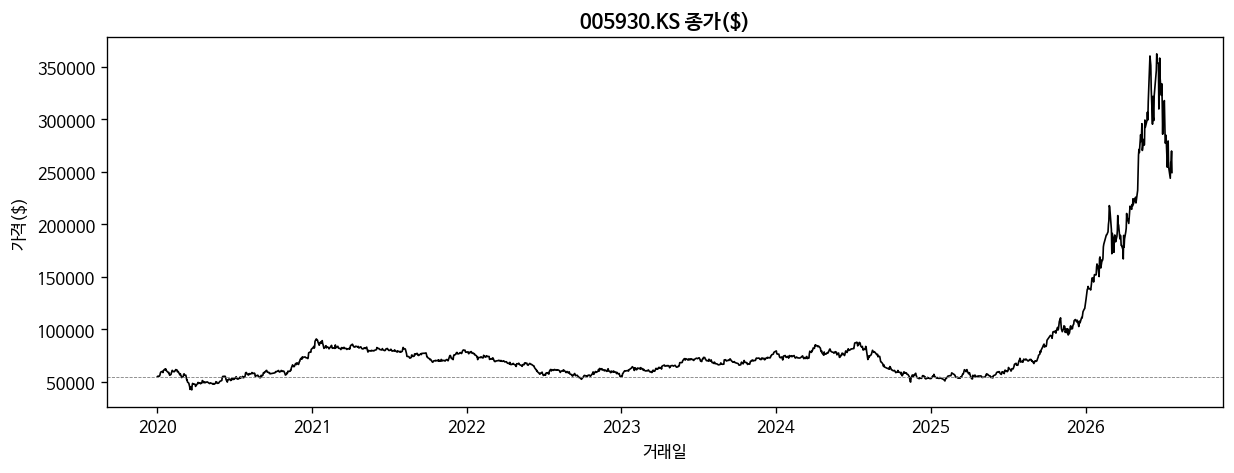

In [114]:
# 종가 추이를 선 그래프로 시각화합니다.
# [참고] color 매개변수에 0~1 범위의 실수를 문자열로 지정할 수 있습니다.
# '0'은 'black', '1'은 'white'이고, '0.5'는 'gray'입니다.
sns.lineplot(data=df, x=df.index, y='Close', color='0', lw=1)
plt.axhline(y=base_close, color='0.5', ls='--', lw=0.5)
plt.xlabel(xlabel='거래일')
plt.ylabel(ylabel='가격($)')
plt.title(label=f'{ticker} 종가($)', fontweight='bold')
plt.show()

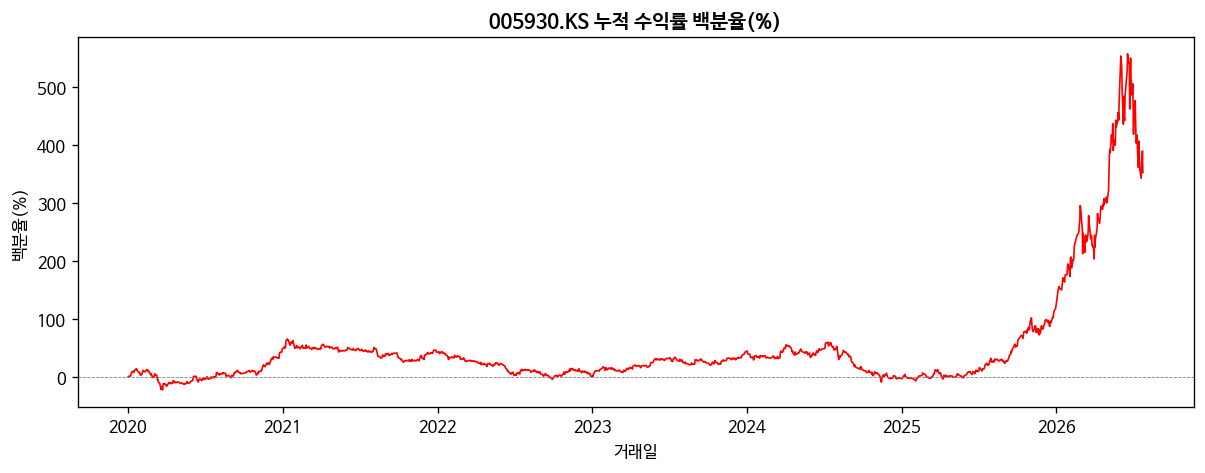

In [115]:
# 누적 수익률 추이를 선 그래프로 시각화합니다.
sns.lineplot(data=df, x=df.index, y='Cum_Return_Pct', color='red', lw=1)
plt.axhline(y=0, color='0.5', ls='--', lw=0.5)
plt.xlabel(xlabel='거래일')
plt.ylabel(ylabel='백분율(%)')
plt.title(label=f'{ticker} 누적 수익률 백분율(%)', fontweight='bold')
plt.show()

In [116]:
# 로그 수익률의 기술통계량을 확인합니다.
df['Log_Return'].describe()

,Log_Return
count,1607.000000
mean,0.000939
std,0.022634
min,-0.131311
25%,-0.010309
50%,0.000000
75%,0.010494
max,0.134606


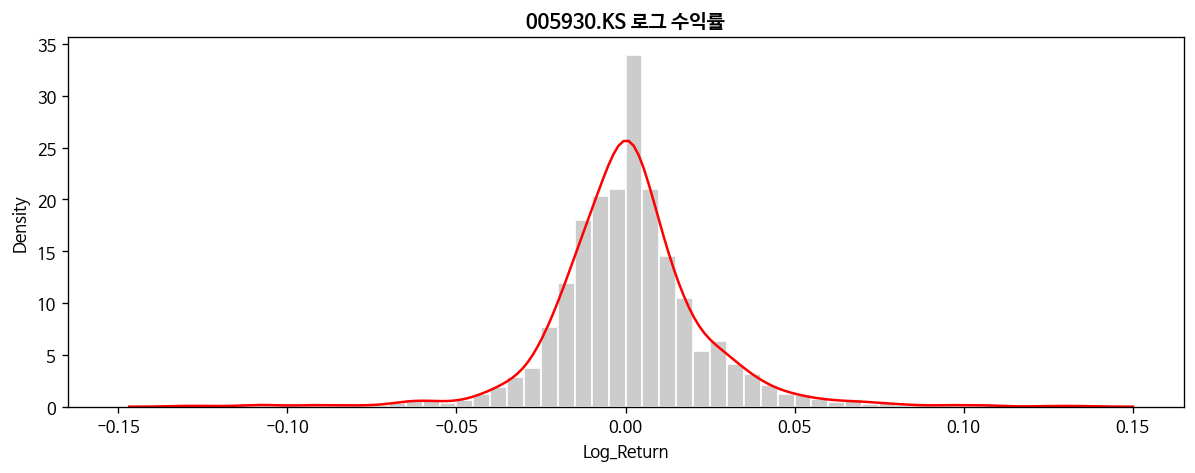

In [117]:
# 로그 수익률을 히스토그램으로 시각화합니다.
# [참고] fc 매개변수는 face color(채우기 색), ec 매개변수는 edge color(테두리 색)을 의미합니다.
# 로그 수익률은 정규분포처럼 보이지만 실제로는 양쪽 꼬리가 정규분포보다 두꺼운 특징을 가집니다.
sns.histplot(data=df, x='Log_Return', fc='0.8', ec='1',
             binrange=(-0.15, 0.15), bins=60, stat='density')
sns.kdeplot(data=df, x='Log_Return', color='red', lw=1.5)
plt.title(label=f'{ticker} 로그 수익률', fontweight='bold')
plt.show()

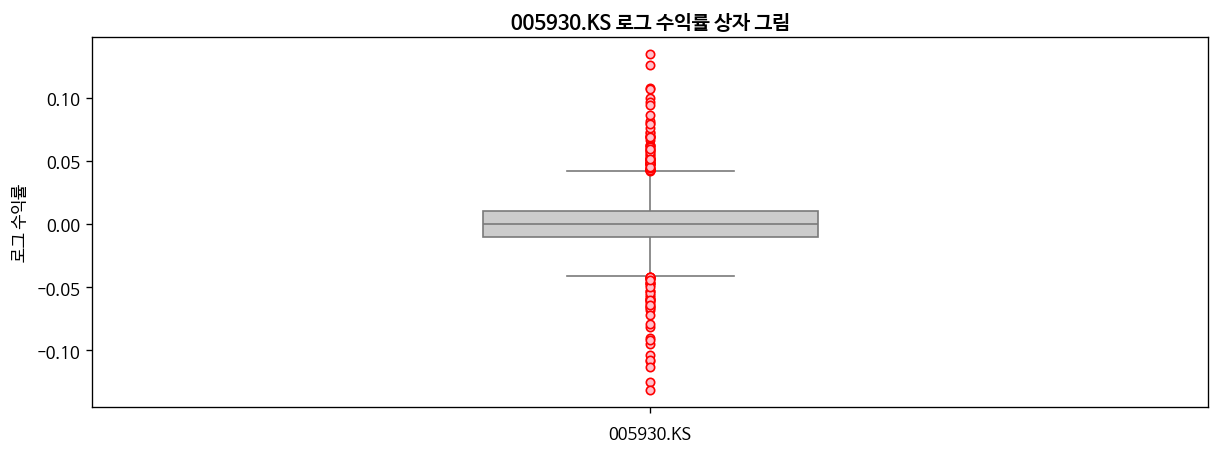

In [118]:
# 로그 수익률의 분포를 상자 그림으로 시각화합니다.
sns.boxplot(data=df, y='Log_Return', color='0.8', width=0.3, fliersize=5,
            flierprops={'markerfacecolor': 'pink', 'markeredgecolor': 'red'})
plt.xlabel(xlabel=f'{ticker}')
plt.ylabel(ylabel='로그 수익률')
plt.title(label=f'{ticker} 로그 수익률 상자 그림', fontweight='bold')
plt.show()

In [119]:
# 필요한 모듈을 임포트합니다.
from scipy import stats

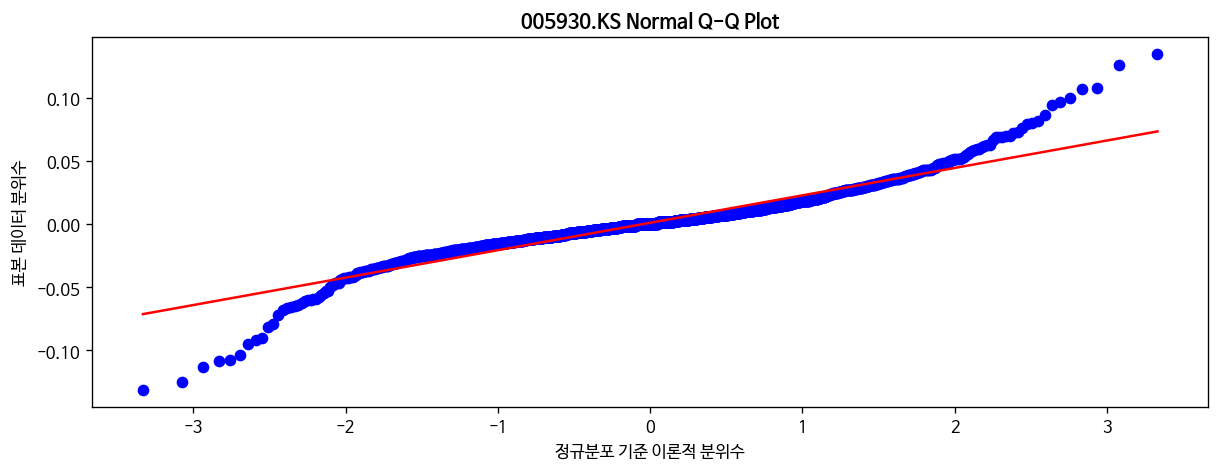

In [120]:
# 로그 수익률을 Normal Q-Q Plot으로 시각화합니다.
# [참고] 모든 점이 빨간색 직선 위에 놓여 있으면 데이터가 정규분포한다고 판단합니다.
stats.probplot(x=df['Log_Return'], dist='norm', plot=plt)
plt.xlabel(xlabel='정규분포 기준 이론적 분위수')
plt.ylabel(ylabel='표본 데이터 분위수')
plt.title(label=f'{ticker} Normal Q-Q Plot', fontweight='bold')
plt.show()

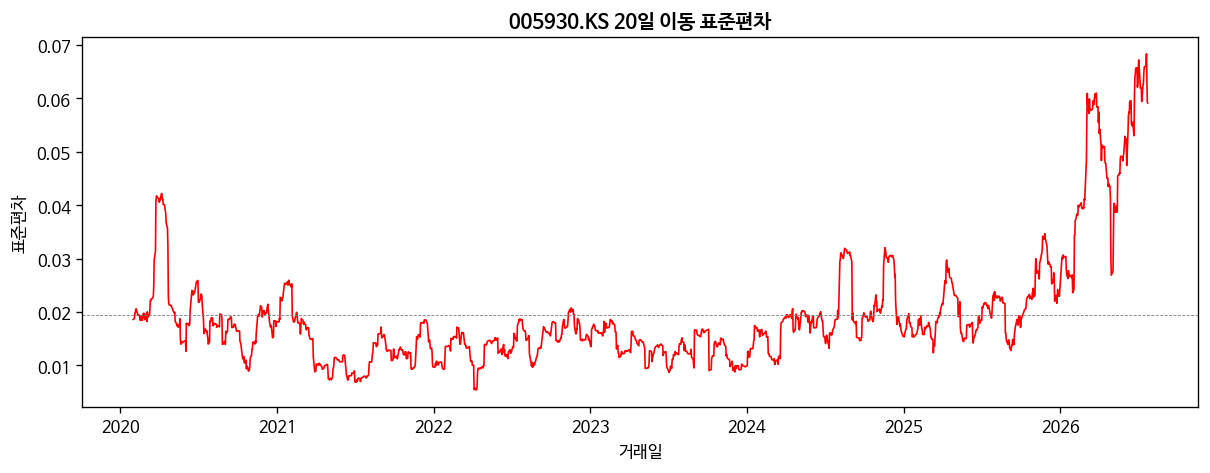

In [121]:
# 이동 변동성을 선 그래프로 시각화합니다.
sns.lineplot(data=df, x=df.index, y='Volatility_20', color='red', lw=1)
plt.axhline(y=df['Volatility_20'].mean(), color='0.5', ls='--', lw=0.5)
plt.xlabel(xlabel='거래일')
plt.ylabel(ylabel='표준편차')
plt.title(label=f'{ticker} 20일 이동 표준편차', fontweight='bold')
plt.show()

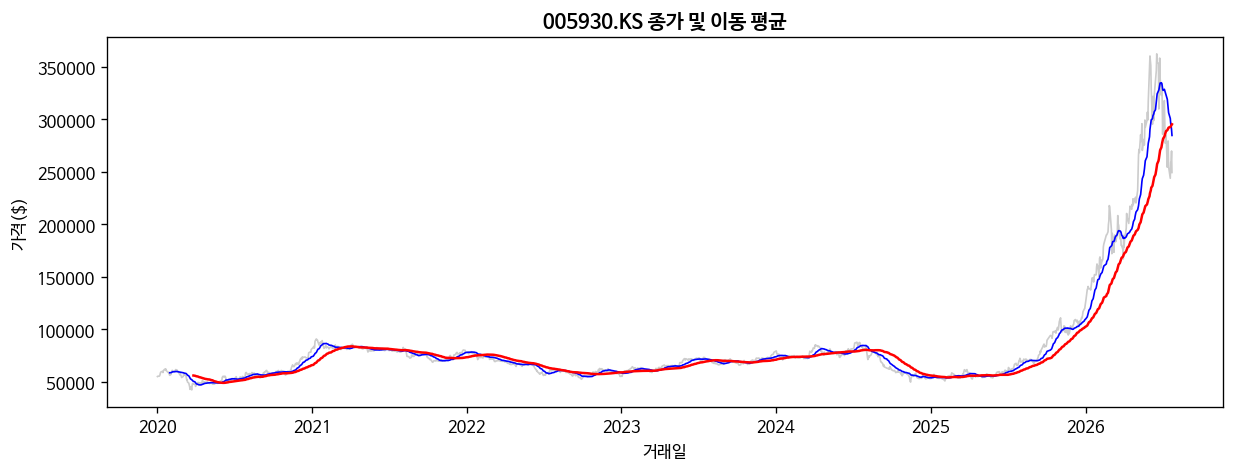

In [125]:
# 이동 평균을 선 그래프로 시각화합니다.
sns.lineplot(data=df, x=df.index, y='Close', color='0.8', lw=1)
sns.lineplot(data=df, x=df.index, y='Moving_Avg_20', color='blue', lw=1)
sns.lineplot(data=df, x=df.index, y='Moving_Avg_60', color='red', lw=1.5)
plt.xlabel(xlabel='거래일')
plt.ylabel(ylabel='가격($)')
plt.title(label=f'{ticker} 종가 및 이동 평균', fontweight='bold')
plt.show()

## End of Document